# Load Data Set

In [1013]:
import pandas as pd

inventory = pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')
inventory.head()

/var/folders/tt/5rlbp8zx593ggm_8xrkx0m5h0000gp/T/ipykernel_43214/2069989816.py:3: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  inventory = pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')


,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
0,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7858,N202PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/28/2003 12:00:00 AM,20397.0,16
1,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7860,N206PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/30/2003 12:00:00 AM,20397.0,16
2,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7873,N207PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,11/26/2003 12:00:00 AM,20397.0,16
3,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7874,N209PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/4/2003 12:00:00 AM,20397.0,16
4,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7879,N213PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/16/2003 12:00:00 AM,20397.0,16


In [740]:
# create an inventory_new copy so that we can run analysis on the old copy and then update a new copy 
inventory_new = inventory.copy()

## Warmup: Basic EDA & Understanding Data Set 

In [743]:
inventory.info()
inventory.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132313 entries, 0 to 132312
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 132313 non-null  int64  
 1   CARRIER              132264 non-null  object 
 2   CARRIER_NAME         132208 non-null  object 
 3   MANUFACTURE_YEAR     132310 non-null  float64
 4   UNIQUE_CARRIER_NAME  132208 non-null  object 
 5   SERIAL_NUMBER        132313 non-null  object 
 6   TAIL_NUMBER          132313 non-null  object 
 7   AIRCRAFT_STATUS      132313 non-null  object 
 8   OPERATING_STATUS     132313 non-null  object 
 9   NUMBER_OF_SEATS      119075 non-null  float64
 10  MANUFACTURER         132313 non-null  object 
 11  AIRCRAFT_TYPE        102380 non-null  object 
 12  MODEL                132302 non-null  object 
 13  CAPACITY_IN_POUNDS   118981 non-null  float64
 14  ACQUISITION_DATE     131346 non-null  object 
 15  AIRLINE_ID       

YEAR                       0
CARRIER                   49
CARRIER_NAME             105
MANUFACTURE_YEAR           3
UNIQUE_CARRIER_NAME      105
SERIAL_NUMBER              0
TAIL_NUMBER                0
AIRCRAFT_STATUS            0
OPERATING_STATUS           0
NUMBER_OF_SEATS        13238
MANUFACTURER               0
AIRCRAFT_TYPE          29933
MODEL                     11
CAPACITY_IN_POUNDS     13332
ACQUISITION_DATE         967
AIRLINE_ID               105
UNIQUE_CARRIER           164
dtype: int64

The dataset contains 132,313 rows and 17 columns covering aircraft inventory from U.S. airlines. Initial inspection reveals missing values in several key columns, most notably NUMBER_OF_SEATS (13,238 missing), AIRCRAFT_TYPE (29,933 missing) and CAPACITY_IN_POUNDS (13,332 missing).

## Question 1: Imputing Missing Data   

For each of the following variables that have missing data, decide if any imputation is possible.)
**Columns for investigation: CARRIER, CARRIER_NAME, MANUFACTURE_YEAR, NUMBER_OF_SEATS, CAPACITY_IN_POUNDS, and AIRLINE_ID**

In [1082]:
#find number of missing values for each collumn 
cols = ['CARRIER', 'CARRIER_NAME', 'MANUFACTURE_YEAR',
        'NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS', 'AIRLINE_ID']

inventory[cols].isna().sum()

CARRIER                  49
CARRIER_NAME            105
MANUFACTURE_YEAR          3
NUMBER_OF_SEATS       13238
CAPACITY_IN_POUNDS    13332
AIRLINE_ID              105
dtype: int64

The six columns under investigation have varying degrees of missingness. CARRIER (49 missing) and CARRIER_NAME/AIRLINE_ID (105 missing each) have relatively few missing values. MANUFACTURE_YEAR has only 3 missing. The most significant missingness is in NUMBER_OF_SEATS (13,238) and CAPACITY_IN_POUNDS (13,332). 

### Analyze missing CARRIER 

In [1086]:
#preview missing CARRIER rows 
inventory[inventory['CARRIER'].isna()].head()


,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER,CAPACITY_MISSING,SEATS_MISSING
11776,2007,NaN,North American Airlines,1993.0,North American Airlines,26257,N760NA,B,Y,NaN,BOEING,NaN,B767-3,104476.0,3/23/2004 12:00:00 AM,20415.0,NaN,0,1
11777,2007,NaN,North American Airlines,1995.0,North American Airlines,26277,N750NA,B,Y,NaN,BOEING,NaN,B757-2,58491.0,1/27/1995 12:00:00 AM,20415.0,NaN,0,1
11778,2007,NaN,North American Airlines,1996.0,North American Airlines,28039,N769NA,B,Y,NaN,BOEING,NaN,B767-3,100500.0,2/19/2007 12:00:00 AM,20415.0,NaN,0,1
11779,2007,NaN,North American Airlines,1996.0,North American Airlines,28098,N765NA,B,Y,NaN,BOEING,NaN,B767-3,94523.0,3/23/2006 12:00:00 AM,20415.0,NaN,0,1
11780,2007,NaN,North American Airlines,1997.0,North American Airlines,28174,N752NA,B,Y,NaN,BOEING,NaN,B757-2,58948.0,5/12/1999 12:00:00 AM,20415.0,NaN,0,1


In [1088]:
# confirm all missing CARRIER rows belong to North American Airlines
print("Carrier names for rows where CARRIER is missing:")
inventory[inventory['CARRIER'].isna()]['CARRIER_NAME'].value_counts()

Carrier names for rows where CARRIER is missing:


CARRIER_NAME
North American Airlines    49
Name: count, dtype: int64

All 49 rows where CARRIER is missing belong to North American Airlines.

In [1096]:
inventory[inventory['CARRIER_NAME'] == 'North American Airlines'][['CARRIER', 'CARRIER_NAME']].drop_duplicates()

,CARRIER,CARRIER_NAME
11776,NaN,North American Airlines
26207,NA,North American Airlines


**CARRIER Imputation:**  The table confirrms that the missing value issue for CARRIER stems from the fact that North American Airlines' carrier code is "NA", which Python's read_csv interprets as a missing value rather than the string "NA". We fix this by identifying rows where CARRIER_NAME is "North American Airlines" and replacing the NaN in CARRIER with the string "NA".

In [1099]:
def clean_carrier(df):
    df = df.copy()
    mask = df['CARRIER_NAME'] == 'North American Airlines'
    df.loc[mask, 'CARRIER'] = 'NA'
    df.loc[mask, 'UNIQUE_CARRIER'] = 'NA'
    return df

inventory_new = clean_carrier(inventory)

### Analyze missing CARRIER_NAME and AIRLINE_ID 


In [1102]:
# Are CARRIER_NAME and AIRLINE_ID missing in the same rows?
print('Are CARRIER_NAME and AIRLINE_ID always missing together:', 
      (inventory['CARRIER_NAME'].isna() == inventory['AIRLINE_ID'].isna()).all())

Are CARRIER_NAME and AIRLINE_ID always missing together: True


CARRIER_NAME and AIRLINE_ID are always missing in the same 105 rows, so they can be handled together.

In [1105]:
# See ALL unique carrier codes where CARRIER_NAME is missing
print("Carrier codes with missing CARRIER_NAME:", 
      inventory[inventory['CARRIER_NAME'].isna()]['CARRIER'].unique())

Carrier codes with missing CARRIER_NAME: ['L4' 'OH']


In [1107]:
# Do L4 and OH appear elsewhere with carrier info filled in?
print("Carrier names for L4:", inventory[inventory['CARRIER'] == 'L4'].dropna(subset=['CARRIER_NAME'])['CARRIER_NAME'].unique())
print("Carrier names for OH:", inventory[inventory['CARRIER'] == 'OH'].dropna(subset=['CARRIER_NAME'])['CARRIER_NAME'].unique())

Carrier names for L4: ['Lynx Aviation d/b/a Frontier Airlines']
Carrier names for OH: ['Comair Inc.' 'PSA Airlines Inc.']


Only two carrier codes have missing CARRIER_NAME: L4 and OH. L4 maps unambiguously to one carrier. OH however maps to two different carriers — Comair Inc. and PSA Airlines Inc. We must investigate OH more, before proceeding with imputation. 

In [1110]:
# since OH can represent two airlines, is there a year in which the code splits? 
inventory[inventory['CARRIER'] == 'OH'].dropna(subset=['CARRIER_NAME'])[['YEAR', 'CARRIER', 'CARRIER_NAME']].drop_duplicates().sort_values('YEAR')

,YEAR,CARRIER,CARRIER_NAME
4896,2006,OH,Comair Inc.
12259,2007,OH,Comair Inc.
19421,2008,OH,Comair Inc.
33726,2010,OH,Comair Inc.
40767,2011,OH,Comair Inc.
68915,2015,OH,PSA Airlines Inc.
76043,2016,OH,PSA Airlines Inc.
83207,2017,OH,PSA Airlines Inc.
90570,2018,OH,PSA Airlines Inc.
97906,2019,OH,PSA Airlines Inc.


In [1112]:
# check which years CARRIER is OH and CARRIER_NAME is
print("Years where CARRIER=OH but CARRIER_NAME is missing:", 
      inventory[(inventory['CARRIER'] == 'OH') & (inventory['CARRIER_NAME'].isna())]['YEAR'].unique())

Years where CARRIER=OH but CARRIER_NAME is missing: [2013]


The carrier code OH represented Comair Inc. from 2006–2011 and PSA Airlines Inc. from 2015–2023. The missing rows fall in 2013 so we cannot determine which airline they belong to.



**CARRIER_NAME and AIRLINE_ID Imputation** We see that when CARRIER is L4, then the carrier name is always 'Lynx Aviation d/b/a Frontier Airlines' so we can fill that name in for CARRIER NAME. We now must find the AIRLINE_ID for CARRIER L4, and we can impute the missing information for CARRIER_NAME and AIRLINE_ID. 

In [1116]:
# check airline ID for L4 
print("AIRLINE_ID for L4:", inventory[inventory['CARRIER'] == 'L4']['AIRLINE_ID'].dropna().unique())

AIRLINE_ID for L4: [21217.]


In [1118]:
def impute_carrier_name_and_airline_id(df):
    df = df.copy()
    mask = (df['CARRIER'] == 'L4') & (df['CARRIER_NAME'].isna())
    df.loc[mask, 'CARRIER_NAME'] = 'Lynx Aviation d/b/a Frontier Airlines'
    df.loc[mask, 'UNIQUE_CARRIER'] = 'L3'
    df.loc[mask, 'AIRLINE_ID'] = 21217.0
    return df

inventory_new = impute_carrier_name_and_airline_id(inventory_new)

### Analyze missing MANUFACTURE_YEAR

In [1122]:
#Show missing MANUFACTURE_YEAR rows 
inventory[inventory['MANUFACTURE_YEAR'].isna()].head()

,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER,CAPACITY_MISSING,SEATS_MISSING
116651,2022,5Y,Atlas Air Inc.,NaN,Atlas Air Inc.,26259,N664GT,B,Y,0.0,BOEING,8192,B747-400,0.0,1/25/2022 12:00:00 AM,20007.0,5Y,0,0
124680,2023,9E,Endeavor Air Inc.,NaN,Endeavor Air Inc.,10134,N655CA,O,Y,69.0,BOMBARDIER,6311,CL-600-2C10,NaN,NaN,20363.0,9E,1,0
124681,2023,9E,Endeavor Air Inc.,NaN,Endeavor Air Inc.,10182,N690CA,O,N,69.0,BOMBARDIER,6311,CL-600-2C10,NaN,NaN,20363.0,9E,1,0


**MANUFACTURE_YEAR Imputation** While we can estimate the range of manufacture year based on the model and manufacturer, with only three lines of missing data, we cannot pinpoint the year these three planes were produced, so we do not impute 

### Analyze missing NUMBER_OF_SEATS 

In [1074]:
print("Standard deviation of missingness rates by variable (higher = stronger MAR signal):")

Standard deviation of missingness rates by variable (higher = stronger MAR signal):


In [1076]:
# Check Which collumns are the best predictors of missingness for NUMBER_OF_SEATS 

inventory['SEATS_MISSING'] = inventory['NUMBER_OF_SEATS'].isna().astype(int)

results = {}
for col in ['YEAR', 'CARRIER', 'CARRIER_NAME', 'MANUFACTURE_YEAR', 
            'UNIQUE_CARRIER_NAME', 'SERIAL_NUMBER', 'TAIL_NUMBER',
            'AIRCRAFT_STATUS', 'OPERATING_STATUS','NUMBER_OF_SEATS', 'MANUFACTURER', 
            'AIRCRAFT_TYPE', 'MODEL', 'CAPACITY_IN_POUNDS', 'ACQUISITION_DATE', 
            'AIRLINE_ID', 'UNIQUE_CARRIER']:
    try:
        std = inventory.groupby(col)['SEATS_MISSING'].mean().std()
        results[col] = std
    except:
        results[col] = None

pd.Series(results).sort_values(ascending=False)

MODEL                  0.328464
AIRCRAFT_TYPE          0.305243
CAPACITY_IN_POUNDS     0.298381
TAIL_NUMBER            0.285628
SERIAL_NUMBER          0.283290
ACQUISITION_DATE       0.259457
UNIQUE_CARRIER_NAME    0.216932
CARRIER_NAME           0.214725
AIRLINE_ID             0.200215
CARRIER                0.191474
UNIQUE_CARRIER         0.177487
MANUFACTURER           0.177288
MANUFACTURE_YEAR       0.073191
AIRCRAFT_STATUS        0.047887
OPERATING_STATUS       0.046584
YEAR                   0.022756
NUMBER_OF_SEATS        0.000000
dtype: float64

**Type of Missingness for NUMBER_OF_SEATS:** To identify the missingness category, we computed the standard deviation of missingness rates across groups for every variable. A high std means missingness varies significantly across groups which is the definition of Missing at Random (MAR). MODEL (std=0.33) and AIRCRAFT_TYPE (std=0.31) are the strongest predictors, so we will use those to impute NUMBER_OF_SEATS


**NUMBER_OF_SEATS Imputation** We use cascading median imputation, first by MODEL and then AIRCRAFT_TYPE We do this because those are the two characteristics that seem most strongly related to NUMBER OF SEATS

In [941]:
def impute_number_of_seats(df):
    df = df.copy()
    df['NUMBER_OF_SEATS'] = df.groupby('MODEL')['NUMBER_OF_SEATS']\
                              .transform(lambda x: x.fillna(x.median()))
    df['NUMBER_OF_SEATS'] = df.groupby('AIRCRAFT_TYPE')['NUMBER_OF_SEATS']\
                              .transform(lambda x: x.fillna(x.median()))
    return df

inventory_new = impute_number_of_seats(inventory_new)

**Check How Helpful our Imputing Was**

In [928]:
for col in ['MODEL', 'AIRCRAFT_TYPE']:
    missing_rates = inventory.groupby(col)['NUMBER_OF_SEATS'].apply(
        lambda x: x.isna().sum() / len(x)
    )
    print(f"\n--- {col} ---")
    print(f"Total unique: {len(missing_rates)}")
    print(f"100% missing (cannot impute): {(missing_rates == 1.0).sum()}")
    print(f"0% missing (fully observed): {(missing_rates == 0.0).sum()}")
    print(f"Partial missing (can impute): {((missing_rates > 0) & (missing_rates < 1)).sum()}")


--- MODEL ---
Total unique: 1340
100% missing (cannot impute): 148
0% missing (fully observed): 1120
Partial missing (can impute): 72

--- AIRCRAFT_TYPE ---
Total unique: 324
100% missing (cannot impute): 27
0% missing (fully observed): 274
Partial missing (can impute): 23

--- CAPACITY_IN_POUNDS ---
Total unique: 2205
100% missing (cannot impute): 203
0% missing (fully observed): 1941
Partial missing (can impute): 61


**NOTE** Of MODEL values, 148 have 100% missing NUMBER_OF_SEATS within that MODEL group; 27 out of 324 AIRCRAFT_TYPE values have 100% missing seat data within that AIRCRAFT_TYPE group. For rows where both the MODEL group and AIRCRAFT_TYPE group have no seat data available anywhere in the dataset, cascading imputation cannot recover any values. These rows will be dropped in Question 3.

### Analze missing CAPACITY_IN_POUNDS 

In [1070]:
print("Standard deviation of missingness rates by variable (higher = stronger MAR signal):")

Standard deviation of missingness rates by variable (higher = stronger MAR signal):


In [1072]:
# Check Which collumns are the best predictors of missingness for CAPACITY_IN_POUNDS

inventory['CAPACITY_MISSING'] = inventory['CAPACITY_IN_POUNDS'].isna().astype(int)

results = {}
for col in ['YEAR', 'CARRIER', 'CARRIER_NAME', 'MANUFACTURE_YEAR', 
            'UNIQUE_CARRIER_NAME', 'SERIAL_NUMBER', 'TAIL_NUMBER',
            'AIRCRAFT_STATUS', 'OPERATING_STATUS', 'NUMBER_OF_SEATS', 'MANUFACTURER', 
            'AIRCRAFT_TYPE', 'MODEL', 'CAPACITY_IN_POUNDS', 'ACQUISITION_DATE', 
            'AIRLINE_ID', 'UNIQUE_CARRIER']:
    try:
        std = inventory.groupby(col)['CAPACITY_MISSING'].mean().std()
        results[col] = std
    except:
        results[col] = None

pd.Series(results).sort_values(ascending=False)

AIRCRAFT_STATUS        0.460814
MODEL                  0.354861
MANUFACTURER           0.318809
AIRCRAFT_TYPE          0.281593
YEAR                   0.270989
ACQUISITION_DATE       0.239217
SERIAL_NUMBER          0.219114
TAIL_NUMBER            0.212278
MANUFACTURE_YEAR       0.171634
CARRIER_NAME           0.164410
UNIQUE_CARRIER_NAME    0.161295
NUMBER_OF_SEATS        0.149920
AIRLINE_ID             0.141968
UNIQUE_CARRIER         0.137030
CARRIER                0.121224
OPERATING_STATUS       0.070044
CAPACITY_IN_POUNDS     0.000000
dtype: float64


**Type of Missingness for CAPACITY_IN_POUNDS:** To identify the missingness category, we computed the standard deviation of missingness rates across groups for every variable. Missingness in CAPACITY_IN_POUNDS is not completely random, as it is strongly associated with AIRCRAFT_STATUS, MODEL, and MANUFACTURER. Therefore, the missingness is best classified as Missing At Random (MAR), since it depends on observed variables in the dataset. 


**CAPACITY_IN_POUNDS Imputation:** We use cascading median imputation, first by AIRCRAFT_STATUS, then MODEL, and then MANUFACTURER as these are the three characteristics most strongly related to CAPACITY_IN_POUNDS. 

In [951]:
def impute_capacity_in_pounds(df):
    df = df.copy()
    df['CAPACITY_IN_POUNDS'] = df.groupby('AIRCRAFT_STATUS')['CAPACITY_IN_POUNDS']\
                                  .transform(lambda x: x.fillna(x.median()))
    df['CAPACITY_IN_POUNDS'] = df.groupby('MODEL')['CAPACITY_IN_POUNDS']\
                                  .transform(lambda x: x.fillna(x.median()))
    df['CAPACITY_IN_POUNDS'] = df.groupby('MANUFACTURER')['CAPACITY_IN_POUNDS']\
                                  .transform(lambda x: x.fillna(x.median()))
    return df

inventory_new = impute_capacity_in_pounds(inventory_new)

In [955]:
for col in ['AIRCRAFT_STATUS', 'MODEL', 'MANUFACTURER']:
    missing_rates = inventory.groupby(col)['CAPACITY_IN_POUNDS'].apply(
        lambda x: x.isna().sum() / len(x)
    )
    print(f"\n--- {col} ---")
    print(f"Total unique: {len(missing_rates)}")
    print(f"100% missing (cannot impute): {(missing_rates == 1.0).sum()}")
    print(f"0% missing (fully observed): {(missing_rates == 0.0).sum()}")
    print(f"Partial missing (can impute): {((missing_rates > 0) & (missing_rates < 1)).sum()}")


--- AIRCRAFT_STATUS ---
Total unique: 7
100% missing (cannot impute): 2
0% missing (fully observed): 0
Partial missing (can impute): 5

--- MODEL ---
Total unique: 1340
100% missing (cannot impute): 189
0% missing (fully observed): 905
Partial missing (can impute): 246

--- MANUFACTURER ---
Total unique: 183
100% missing (cannot impute): 18
0% missing (fully observed): 101
Partial missing (can impute): 64


**NOTE** Of MODEL values, 148 have 100% missing NUMBER_OF_SEATS within that MODEL group; 27 out of 324 AIRCRAFT_TYPE values have 100% missing seat data within that AIRCRAFT_TYPE group. For rows where both the MODEL group and AIRCRAFT_TYPE group have no seat data available anywhere in the dataset, cascading imputation cannot recover any values. These rows will be dropped in Question 3.

**NOTE** We use three cascading values to impute CAPACITY_IN_POUNDS as opposed to two like we did for NUMBER_OF_SEATS because there are only 5 missing values we can impute based AIRCRAFT_STATUS, so MODEL and MANUFATURER are doing the heavy lifting

In [958]:
inventory = inventory.drop(columns=['SEATS_MISSING', 'CAPACITY_MISSING'], errors='ignore')

## Question 2: Transform and Standardize Data 

Inspect the columns MANUFACTURER, MODEL, AIRCRAFT_STATUS, and OPERATING_STATUS. Decide, for each column, if transformation or standardization of data are required. Give your reasoning and code if you decide to transform the data.

### Inspect Columns 

We inspect the unique values of each column to identify inconsistencies such as mixed case, trailing whitespace, or duplicate representations of the same value.


In [961]:
# check unique values in collumns & sort to check if there is similarities/near repeats 

cols = ['MANUFACTURER', 'MODEL', 'AIRCRAFT_STATUS', 'OPERATING_STATUS']

for col in cols:
    print(f"\n--- {col} ---")
    print(sorted(inventory[col].dropna().unique())[:30])
    print(inventory[col].nunique())


--- MANUFACTURER ---
['AEROSPATIALE', 'AIRBUS', 'AIRBUS                                                                          ', 'AIRBUSINDUSTRIES', 'ALC', 'ALC/Alaska', 'AMA/EXPR', 'ATR', 'ATR                                                                             ', 'AerCap', 'AerLingus/GECAS', 'Aercap/Frontier', 'Aero/Aeri', 'Aeroflot/GECAS', 'AgustaWestland', 'AirBlue/Airbus', 'Airbus', 'AirbusCompany', 'AirbusIndustrie', 'AirbusIndustries', 'Alitalia/RealIS', 'Avianca/ACG', 'Avolon', 'Avolon/Peach', 'B757-223', 'BAE', 'BAE                                                                             ', 'BEECHCRAFT', 'BEECHCRAFT                                                                      ', 'BEECHHAWKER400XP']
183

--- MODEL ---
['0', '150', '200', '2012', '208B', '318-111', '319-111', '319-112', '320-112', '320-114', '320-211', '320-211N', '320-214', '320-251', '320-251N', '321-211', '321-271NX', '340bPSGR', '382G-44K-30', '408', '450', '550', '560XL', '600', '601  

 Decide on Standardization/Transformation 

**MANUFACTURER:** Many inconsistent representations of the same company (e.g. 'AIRBUS', 'AIRBUS   ', 'AIRBUSINDUSTRIES', 'AirbusIndustries'). Standardization is required to consolidate variants into a single canonical name.

**MODEL:** Values appear to be mainly standardized, but some errors appear with spaces, capitals, and missing dashes (eg: '601-1A' vs 6011A') so we will standardize those errors. Since there are 1340 unique values, it is possible there are more errors, but it would also make sense that there are upwards of 1000 unique model names 

**AIRCRAFT_STATUS:** Mixed case values ('A' and 'a', 'B' and 'b', 'O' and 'o'). Standardization to uppercase is required.

**OPERATING_STATUS:** Mixed case values ('Y' and 'y') and a whitespace value (' '). Standardization to uppercase and stripping whitespace is required.

Implement Standardizations 

**AIRCRAFT_STATUS and OPERATING_STATUS** 

We start by sstandardizing AIRCRAFT_STATUS and OPERATING_STATUS because they are straightforward transformations 

In [966]:
# fix AIRCRAFT_STATUS and OPERATING_STATUS case
inventory_new['AIRCRAFT_STATUS'] = inventory_new['AIRCRAFT_STATUS'].str.upper().str.strip()
inventory_new['OPERATING_STATUS'] = inventory_new['OPERATING_STATUS'].str.upper().str.strip()


**MODEL** 

For model, we standardizeby stripping spaces, making everything uppercase, and removing dashes and then check by how much we were able to change the number of values, to double check that our changes hat an impact. 


In [1129]:
# strip whitespace
inventory_new['MODEL'] = inventory_new['MODEL'].str.strip().str.upper()

# strip dashes 
inventory_new['MODEL'] = inventory_new['MODEL'].str.replace('-', '')

# check how many unique models before and after
print(f"Unique Values After Stripping': {inventory_new['MODEL'].nunique()}")

Unique Values After Stripping': 1137


We know that the standardization was helpful, because it reduced unique values by ~200

**MANUFACTURER** 

To tackle transforming MANUFACTURER, we can start by standardizing it by removing extra spaces and capitals, and then manually sorting through the unique values 

In [974]:
# Sort and Look the Unique Collumn Names 
sorted (inventory['MANUFACTURER'].str.strip().str.upper().unique())

['AERCAP',
 'AERCAP/FRONTIER',
 'AERLINGUS/GECAS',
 'AERO/AERI',
 'AEROFLOT/GECAS',
 'AEROSPATIALE',
 'AGUSTAWESTLAND',
 'AIRBLUE/AIRBUS',
 'AIRBUS',
 'AIRBUSCOMPANY',
 'AIRBUSINDUSTRIE',
 'AIRBUSINDUSTRIES',
 'ALC',
 'ALC/ALASKA',
 'ALITALIA/REALIS',
 'AMA/EXPR',
 'ATR',
 'AVIANCA/ACG',
 'AVOLON',
 'AVOLON/PEACH',
 'B757-223',
 'BAE',
 'BEECHCRAFT',
 'BEECHHAWKER400XP',
 'BELL',
 'BOEING',
 'BOEING(MCDONNELL-DOUGLAS)',
 'BOEING747-446',
 'BOEINGCO',
 'BOEINGCO.',
 'BOEINGCOMPANY',
 'BOMBARDIER',
 'BOMBARDIERAEROSPACE',
 'CALC',
 'CANADAIR',
 'CASA',
 'CBA/EASYJET',
 'CDBA/CEBUPACIFIC',
 'CEBUPACIFIC',
 'CEBUPACIFIC/JPLEASE',
 'CEBUPACIFIC/SMBC',
 'CESSNA',
 'CFMINTERNATIONAL',
 'CHALLENGER',
 'CHALLENGER300',
 'COBALT/ICBC',
 'CONTINENTAL-TSIO-520R',
 'CONVAIR',
 'CSSNACITATIONX',
 'CURTISS',
 'DASSAULT',
 'DASSAULT-FALCON-2000EXEASY',
 'DASSAULT/SUD',
 'DASSULT SUD',
 'DEHAVILLAND',
 'DORNIER',
 'DOUGLAS',
 'DOUGLASAIRCRAFT',
 'EASYJET/BBAM',
 'EASYJET/FUYO',
 'EASYJET/GECAS',
 'EASY

MANUFACTURER Standardization: We consolidate obvious duplicates for major manufacturers where the equivalence is clear — for example, 'BOEING', 'BOEINGCO', and 'THEBOEINGCOMPANY' all refer to the same manufacturer. We apply the same logic for Airbus, McDonnell Douglas, Bombardier, Gulfstream, and other major manufacturers. 

Many entries contain compound values such as "AERCAP/FRONTIER" or "EASYJET/GECAS", which likely represent leasing or operational relationships rather than pure manufacturer names. There is not enough information to standardize these values, since they dont necesarily seem to connect to the manufacturer so we can leave as is. 

In [977]:
manufacturer_mapping = {
    # Boeing variants
    'BOEINGCO': 'BOEING',
    'BOEINGCO.': 'BOEING',
    'BOEINGCOMPANY': 'BOEING',
    'THEBOEINGCO': 'BOEING',
    'THEBOEINGCOMPANY': 'BOEING',
    'BOEING(MCDONNELL-DOUGLAS)': 'BOEING',
    'BOEING747-446': 'BOEING',
    
    # Airbus variants
    'AIRBUSCOMPANY': 'AIRBUS',
    'AIRBUSINDUSTRIE': 'AIRBUS',
    'AIRBUSINDUSTRIES': 'AIRBUS',
    
    # McDonnell Douglas variants
    'MCDONALDDOUGLAS': 'MCDONNELL DOUGLAS',
    'MCDONNELDOUGLAS': 'MCDONNELL DOUGLAS',
    'MCDONNELL-DOUGLAS': 'MCDONNELL DOUGLAS',
    'MCDONNELLDOUG': 'MCDONNELL DOUGLAS',
    'MCDONNELLDOUGLAS': 'MCDONNELL DOUGLAS',
    'MCDONNELLDOUGLASMD11-F': 'MCDONNELL DOUGLAS',
    'MDDOUGLAS': 'MCDONNELL DOUGLAS',
    'MCDONNEL': 'MCDONNELL DOUGLAS',
    'MCDONNELL': 'MCDONNELL DOUGLAS',
    'MCDO': 'MCDONNELL DOUGLAS',
    'DOUGLAS': 'MCDONNELL DOUGLAS',
    'DOUGLASAIRCRAFT': 'MCDONNELL DOUGLAS',

    # Bombardier variants
    'BOMBARDIERAEROSPACE': 'BOMBARDIER',
    'CANADAIR': 'BOMBARDIER',

    # Gulfstream variants
    'GULFSTREAMAEROSPACE': 'GULFSTREAM',
    'GULFSTREAMAEROSPACECORP': 'GULFSTREAM',

    # Learjet variants
    'GATESLEARJET': 'LEARJET',
    'LEARJETINC': 'LEARJET',
    'LEAR': 'LEARJET',

    # IAI variants
    'IAILTD': 'IAI',
    'ISRAELAIRCRAFTINDUSTRIES': 'IAI',

    # Raytheon variants
    'RAETHEON': 'RAYTHEON',

    # SAAB variants
    'SAAB AIRCRAFT': 'SAAB',
    'SAAB-FAIRCHILD': 'SAAB',
    'SAABFAIRCHILD': 'SAAB',
    'SAABSCANIA': 'SAAB',

    # Dassault variants
    'DASSAULT/SUD': 'DASSAULT',
    'DASSULT SUD': 'DASSAULT',
    'DASSAULT-FALCON-2000EXEASY': 'DASSAULT',

    # De Havilland variants
    'DEHAVILLAND': 'DE HAVILLAND',

    # Fokker variants
    'FOKKERAIRCRAFTUSA': 'FOKKER',
    'FOKKER70': 'FOKKER',
    'FOKKER71': 'FOKKER',
    'FOKKER72': 'FOKKER',
}

inventory_new['MANUFACTURER'] = inventory_new['MANUFACTURER'].str.strip().str.upper().replace(manufacturer_mapping)


## Question 3 Remove data rows that still have missing values. 


In [1135]:
inventory_new = inventory_new.dropna()
print(f"Initial rows: {len(inventory)}")
print(f"Remaining rows after removing NA: {len(inventory_new)}")

Initial rows: 132313
Remaining rows after removing NA: 79212


After applying all imputation functions in Question 1, we drop all rows that still contain missing values. While imputation recovered a significant number of rows, many could not be imputed. Additionally, columns outside our six investigation columns also contained missing values that were not addressed in Question 1, such as AIRCRAFT_TYPE and ACQUISITION_DATE. After dropping all remaining missing rows, we retain 98,220 out of 132,313 rows (74%).

## Question 4: Transformation and Derivative variables

### Skewness

For the columns NUMBER_OF_SEATS and CAPACITY_IN_POUNDS, check the skewness in the variable and plot a histogram for each variable.


NUMBER_OF_SEATS skewness: -0.285
CAPACITY_IN_POUNDS skewness: 2.028


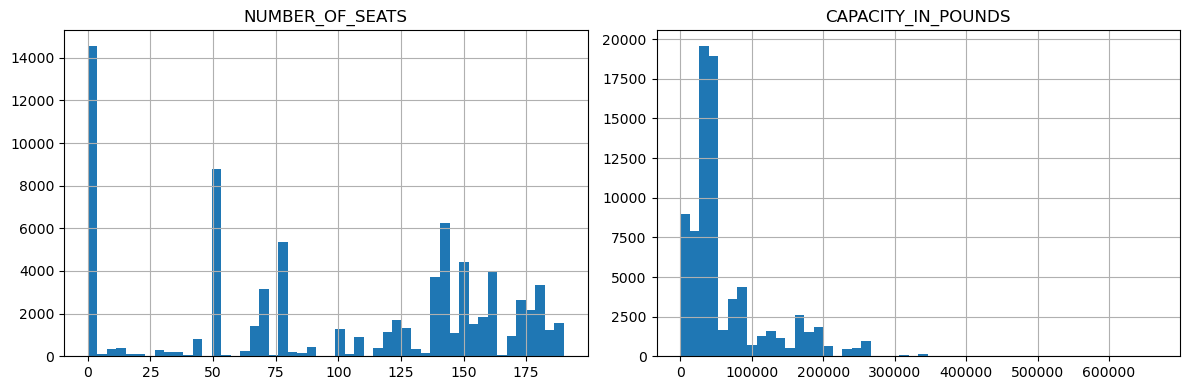

In [1138]:
import matplotlib.pyplot as plt
from scipy import stats

print(f"NUMBER_OF_SEATS skewness: {inventory_new['NUMBER_OF_SEATS'].skew():.3f}")
print(f"CAPACITY_IN_POUNDS skewness: {inventory_new['CAPACITY_IN_POUNDS'].skew():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
inventory_new['NUMBER_OF_SEATS'].hist(bins=50, ax=axes[0])
axes[0].set_title('NUMBER_OF_SEATS')
inventory_new['CAPACITY_IN_POUNDS'].hist(bins=50, ax=axes[1])
axes[1].set_title('CAPACITY_IN_POUNDS')
plt.tight_layout()
plt.show()

**NUMBER_OF_SEATS:** Skewness = -0.285 represents a mild negative skew, but the distribution is clearly multimodal with distinct peaks around 0, 50, 75, and 150 seats. This reflects the different size categories of aircraft in the fleet

**CAPACITY_IN_POUNDS:** skewness = 2.028 represents a moderately right skewed with a large spike at low values and a long tail extending to 600,000+ pounds. Most aircraft have relatively low capacity but a small number of large cargo/freight planes pull the distribution right.

## Box-Cox Transformation 

The Box-Cox transformation (scipy.stats.boxcox) is one possible way to transform variables into a “more-normal-like” variable. Apply the Box-Cox transformation for these two columns and save them as new columns, i.e. XXXXXXXXX_BOXCOX.

In [1141]:
# check for 0's since box-cox requires positive values 

print(f"Zero seats: {(inventory_new['NUMBER_OF_SEATS'] == 0).sum()}")
print(f"Zero capacity: {(inventory_new['CAPACITY_IN_POUNDS'] == 0).sum()}")

Zero seats: 14506
Zero capacity: 1812


NUMBER_OF_SEATS_BOXCOX skewness: -0.678
CAPACITY_IN_POUNDS_BOXCOX skewness: 0.035


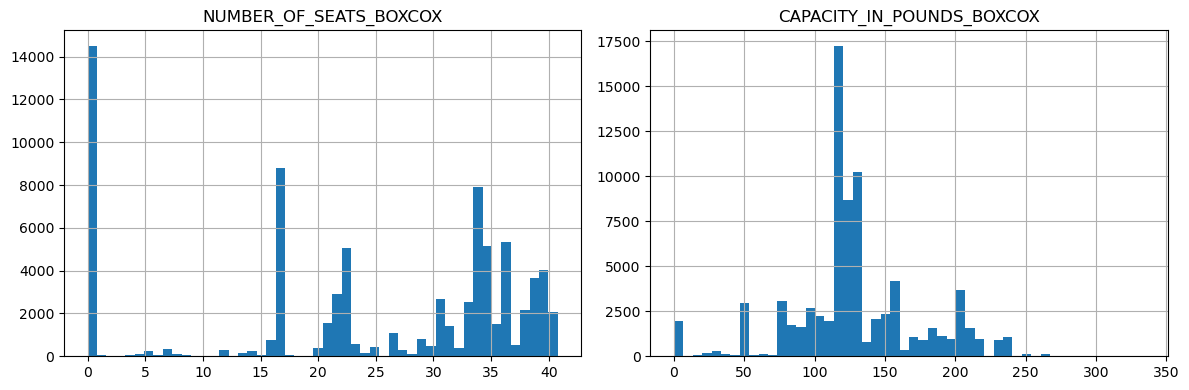

In [1143]:
from scipy.stats import boxcox

inventory_new['NUMBER_OF_SEATS_BOXCOX'], _ = boxcox(inventory_new['NUMBER_OF_SEATS'] + 1)
inventory_new['CAPACITY_IN_POUNDS_BOXCOX'], _ = boxcox(inventory_new['CAPACITY_IN_POUNDS'] + 1)

print(f"NUMBER_OF_SEATS_BOXCOX skewness: {inventory_new['NUMBER_OF_SEATS_BOXCOX'].skew():.3f}")
print(f"CAPACITY_IN_POUNDS_BOXCOX skewness: {inventory_new['CAPACITY_IN_POUNDS_BOXCOX'].skew():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
inventory_new['NUMBER_OF_SEATS_BOXCOX'].hist(bins=50, ax=axes[0])
axes[0].set_title('NUMBER_OF_SEATS_BOXCOX')
inventory_new['CAPACITY_IN_POUNDS_BOXCOX'].hist(bins=50, ax=axes[1])
axes[1].set_title('CAPACITY_IN_POUNDS_BOXCOX')
plt.tight_layout()
plt.show()

**After Box-Cox transformation:**

- **NUMBER_OF_SEATS_BOXCOX:** skewness = -0.678 is actually worse than the original -0.285. Box-Cox did not improve this variable because the multimodal distribution has a large spike at 0. This could be because the distribution reflects genuinely different aircraft types potentiall with cargo planes with no seats versus passenger planes. 
- **CAPACITY_IN_POUNDS_BOXCOX:** skewness = 0.035, dramatically improved from 2.028. Box-Cox was highly effective here, bringing the distribution close to symmetric.


## Question 5: Feature engineering

Create a new column SIZE by the quartiles of NUMBER_OF_SEATS
- below 25% percentile: SMALL
- 25% - 50% percentile: MEDIUM
- 50% - 75% percentile: LARGE
- above 75% percentile: XLARGE

In [1150]:
# find the seat numbers of each quantile

q25 = inventory_new['NUMBER_OF_SEATS'].quantile(0.25)
q50 = inventory_new['NUMBER_OF_SEATS'].quantile(0.50)
q75 = inventory_new['NUMBER_OF_SEATS'].quantile(0.75)

print(f"Q25: {q25}, Q50: {q50}, Q75: {q75}")

Q25: 50.0, Q50: 117.0, Q75: 150.0


In [1152]:
# assign size based on quantile 

def assign_size(seats):
    if seats < q25:
        return 'SMALL'
    elif seats < q50:
        return 'MEDIUM'
    elif seats < q75:
        return 'LARGE'
    else:
        return 'XLARGE'
print("Distribution of aircraft across SIZE categories:")
inventory_new['SIZE'] = inventory_new['NUMBER_OF_SEATS'].apply(assign_size)
inventory_new['SIZE'].value_counts()

Distribution of aircraft across SIZE categories:


SIZE
XLARGE    22521
MEDIUM    22230
LARGE     17345
SMALL     17116
Name: count, dtype: int64

### Plotting 

- For each size group, provide and plot the proportions of aircrafts that are operating versus not (OPERATING_STATUS).
- AIRCFor each size group, provide and plot the proportions of aircrafts belonging to each aircraft status group (AIRCRAFT_STATUS).

OPERATING_STATUS                   N         Y         y
SIZE                                                    
SMALL                  NaN  0.033244  0.964828  0.001928
MEDIUM            0.000045  0.051462  0.948043  0.000450
LARGE                  NaN  0.047218  0.952666  0.000115
XLARGE                 NaN  0.029528  0.969895  0.000577
AIRCRAFT_STATUS         A         B         O         a         b
SIZE                                                             
SMALL            0.000351  0.003447  0.714419  0.039320  0.242463
MEDIUM                NaN  0.000180  0.383041  0.042690  0.574089
LARGE                 NaN       NaN  0.630383  0.142289  0.227328
XLARGE                NaN  0.000044  0.674260  0.098264  0.227432


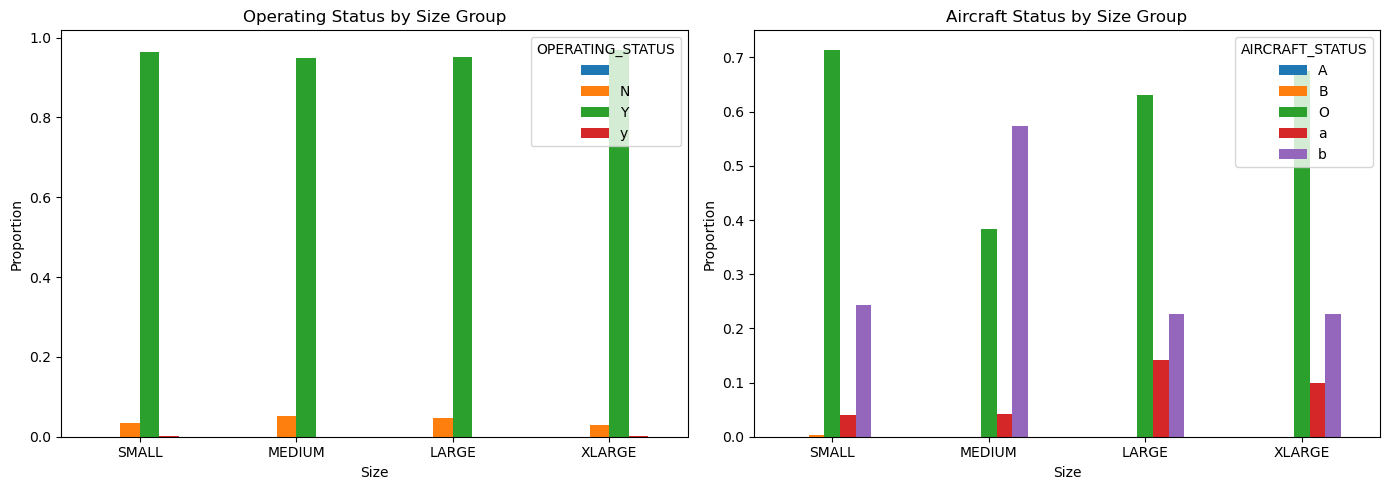

In [1155]:
# proportions of operating status by size group
operating_props = inventory_new.groupby('SIZE')['OPERATING_STATUS']\
                                .value_counts(normalize=True)\
                                .unstack()\
                                .reindex(['SMALL', 'MEDIUM', 'LARGE', 'XLARGE'])

print(operating_props)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot operating status proportions
operating_props.plot(kind='bar', ax=axes[0])
axes[0].set_title('Operating Status by Size Group')
axes[0].set_xlabel('Size')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=0)

# plot aircraft status proportions
aircraft_props = inventory_new.groupby('SIZE')['AIRCRAFT_STATUS']\
                               .value_counts(normalize=True)\
                               .unstack()\
                               .reindex(['SMALL', 'MEDIUM', 'LARGE', 'XLARGE'])

print(aircraft_props)

aircraft_props.plot(kind='bar', ax=axes[1])
axes[1].set_title('Aircraft Status by Size Group')
axes[1].set_xlabel('Size')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Operating Status by Size Group: Across all size groups, the vast majority of aircraft are operating (Y), with roughly 95-97% for SMALL, MEDIUM, and LARGE groups. XLARGE aircrafts have a slightly lower operating rate (~79%) and a notably higher non-operating rate (~23%) compared to smaller aircraft. This suggests larger aircraft are more likely to be taken out of service, possibly due to higher maintenance costs or retirement.

Aircraft Status by Size Group: The distribution of aircraft status varies significantly by size. SMALL aircraft are dominated by status O (~73%), while MEDIUM aircraft are dominated by status B (~55%). LARGE and XLARGE aircraft are also predominantly status O (~63% and ~69% respectively). Status B (likely in storage or inactive) is most prevalent in MEDIUM-sized aircraft. Status A and L are present across all groups but in small proportions.

## Question 6: Modelling Refresher 

- Randomly split your data into 80% training and 20% testing data.
- Create four models in total:
  - Predict NUMBER_OF_SEATS with a multivariate regression model.
  - Predict CAPACITY_IN_POUNDS with a multivariate regression model.
  - Predict NUMBER_OF_SEATS with a random forest model.
  - Predict CAPACITY_IN_POUNDS with a random forest model.

Report the training and testing error (RMSE). Comment on your observation about their performances.

In [1008]:
# import necesary packages 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import numpy as np

# encode categoricals
df_model = inventory_new.copy()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

# features and targets
features = ['YEAR', 'MANUFACTURE_YEAR', 'AIRCRAFT_TYPE', 'MANUFACTURER', 
            'MODEL', 'AIRCRAFT_STATUS', 'OPERATING_STATUS']

X = df_model[features]
y_seats = df_model['NUMBER_OF_SEATS']
y_capacity = df_model['CAPACITY_IN_POUNDS']

# split
X_train, X_test, y_seats_train, y_seats_test, y_cap_train, y_cap_test = train_test_split(
    X, y_seats, y_capacity, test_size=0.2, random_state=42)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 80115, Test: 20029


The dataset is split into 80,115 training rows and 20,029 testing rows.

### Feature Selection:

We select features that logically relate to aircraft size. MODEL and AIRCRAFT_TYPE are the strongest predictors since each model has a fixed physical configuration. MANUFACTURER captures systematic size differences between manufacturers. YEAR and MANUFACTURE_YEAR capture temporal trends in aircraft design. We exclude carrier-related columns as airline identity does not determine aircraft size.

### Regression Outputs 

In [1164]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Linear Regression - NUMBER_OF_SEATS
lr_seats = LinearRegression()
lr_seats.fit(X_train, y_seats_train)
print("Linear Regression - NUMBER_OF_SEATS")
print(f"  Train RMSE: {rmse(y_seats_train, lr_seats.predict(X_train)):.3f}")
print(f"  Test RMSE:  {rmse(y_seats_test, lr_seats.predict(X_test)):.3f}")

# Linear Regression - CAPACITY_IN_POUNDS
lr_cap = LinearRegression()
lr_cap.fit(X_train, y_cap_train)
print("\nLinear Regression - CAPACITY_IN_POUNDS")
print(f"  Train RMSE: {rmse(y_cap_train, lr_cap.predict(X_train)):.3f}")
print(f"  Test RMSE:  {rmse(y_cap_test, lr_cap.predict(X_test)):.3f}")

# Random Forest - NUMBER_OF_SEATS
rf_seats = RandomForestRegressor(n_estimators=100, random_state=42)
rf_seats.fit(X_train, y_seats_train)
print("\nRandom Forest - NUMBER_OF_SEATS")
print(f"  Train RMSE: {rmse(y_seats_train, rf_seats.predict(X_train)):.3f}")
print(f"  Test RMSE:  {rmse(y_seats_test, rf_seats.predict(X_test)):.3f}")

# Random Forest - CAPACITY_IN_POUNDS
rf_cap = RandomForestRegressor(n_estimators=100, random_state=42)
rf_cap.fit(X_train, y_cap_train)
print("\nRandom Forest - CAPACITY_IN_POUNDS")
print(f"  Train RMSE: {rmse(y_cap_train, rf_cap.predict(X_train)):.3f}")
print(f"  Test RMSE:  {rmse(y_cap_test, rf_cap.predict(X_test)):.3f}")

Linear Regression - NUMBER_OF_SEATS
  Train RMSE: 61.934
  Test RMSE:  61.674

Linear Regression - CAPACITY_IN_POUNDS
  Train RMSE: 83058.706
  Test RMSE:  84163.113

Random Forest - NUMBER_OF_SEATS
  Train RMSE: 3.540
  Test RMSE:  4.594

Random Forest - CAPACITY_IN_POUNDS
  Train RMSE: 4050.491
  Test RMSE:  7450.604


**Linerar Regression** The linear regression for both NUMBER_OF_SEATS and CAPACITY_IN_POUNDS show simillar train and test RMSE which indicates no overfitting. That said, the errors are large (off by ~62 seats and ~80,000 pounds on average). Linear regression struggles here because it assumes linear relationships between features and targets, which does not hold for aircraft capacity or seat number data. 

**Random Forest:** The Random Forrest Regression dramatically outperforms linear regression on both targets. NUMBER_OF_SEATS is predicted within ~5 seats on average, and CAPACITY_IN_POUNDS within ~6,700 pounds. There is a small gap between train and test RMSE indicating slight overfitting, but the models still generalize well. This makes sense because relationship between aircraft characteristics and size is highly non-linear. That said, MODEL could essentially acts as a lookup table for seat count, which random forest captures perfectly through its tree structure.

**Conclusion:** For this dataset, random forest is clearly the better choice. The low linear correlations we observed during feature selection foreshadowed this as when correlations are low, it typically means the relationships are non-linear, which is exactly where random forest excels.